In [14]:
from sklearn.model_selection import KFold, cross_validate, RepeatedKFold
from sklearn.preprocessing import PowerTransformer,  StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression, HuberRegressor

from ml_enhance import CorrelationFilter

from sklearn import pipeline
import pandas as pd
import numpy as np
import pickle
import json

In [2]:
def make_pipeline(model, step_name):
    return pipeline.Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("remove_corr", CorrelationFilter(threshold=0.95)),
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", StandardScaler()),
        (step_name, model)
    ])

In [3]:
pl_linear = make_pipeline(LinearRegression(), "predict")
pl_huber = make_pipeline(HuberRegressor(), "predict")

As the data (even after transformation and scaling) consists of a lot of outliers that cannot be removed (as they are valid molecules and are therefore part of the real world observables) I decided to use [Huber regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html) instead of linear regression, this method is more robust to outliers.

In [4]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm.csv")

In [5]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [6]:
X = X.drop([
        "avg_atomic_quadrupole_principal_invariant_3", # quadrupole principal invariant 3 features correlate highly with the invariant 2 features, so can drop them
        "max_atomic_quadrupole_principal_invariant_3",
        "molecular_quadrupole_principal_invariant_3",
        "avg_atomic_dipole_dipole_interaction" # the dipole dipole interaction between atoms would physically not be that influential on the solubility, can drop it
    ], axis=1)

In [7]:
with open("../data/rdkit_feature_names.json", "r") as f:
    rdkit_feature_list: list = json.load(f)

mask = X.columns.isin(rdkit_feature_list)

In [8]:
X_topo = X.iloc[:, mask]
X_qm = X.iloc[:, ~mask]

## Huber Regression: Topology VS. QM + Topology

In [9]:
inner_kf = KFold(n_splits=5, shuffle=True, random_state=42)
repeated_kf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=15)

In [10]:
scoring = {
    "r2": "r2",
    "MSE": "neg_mean_squared_error"
}

In [11]:
param_grid = {
    "predict__epsilon": [1.1, 1.35, 1.5, 2.0],
    "predict__alpha": [1e-5, 1e-4, 1e-3, 1e-2]
}

In [12]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=pl_huber,
    param_grid=param_grid,
    cv=inner_kf,
    scoring='r2',
    n_jobs=1
)

In [ ]:
# scores_combo = cross_validate(grid, X, y, cv=repeated_kf, scoring=scoring, n_jobs=5, return_estimator=True, return_train_score=True, verbose=10)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed: 28.6min
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed: 43.4min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed: 72.1min
[Parallel(n_jobs=4)]: Done  21 out of  25 | elapsed: 86.3min remaining: 16.4min
[Parallel(n_jobs=4)]: Done  25 out of  25 | elapsed: 96.9min finished


In [ ]:
# with open("HuberReg_combo.pkl", "wb") as f:
#     pickle.dump(scores_combo, f)

In [15]:
with open("HuberReg_combo.pkl", "rb") as f:
    scores_combo = pickle.load(f)

In [43]:
for idx in range(25):
    print(scores_combo["estimator"][idx].best_score_, scores_combo["estimator"][idx].best_params_)

0.7986405597224142 {'predict__alpha': 0.01, 'predict__epsilon': 2.0}
0.8313495592092293 {'predict__alpha': 0.01, 'predict__epsilon': 1.5}
0.6315193511634017 {'predict__alpha': 1e-05, 'predict__epsilon': 1.1}
0.82253205743748 {'predict__alpha': 0.0001, 'predict__epsilon': 2.0}
0.8243286118679954 {'predict__alpha': 1e-05, 'predict__epsilon': 2.0}
0.823065278401527 {'predict__alpha': 0.01, 'predict__epsilon': 2.0}
0.7782851719390478 {'predict__alpha': 0.001, 'predict__epsilon': 1.5}
0.7727487964027856 {'predict__alpha': 1e-05, 'predict__epsilon': 1.1}
0.8246003765618056 {'predict__alpha': 0.01, 'predict__epsilon': 2.0}
0.8234532915040585 {'predict__alpha': 0.01, 'predict__epsilon': 1.5}
0.831764227089818 {'predict__alpha': 1e-05, 'predict__epsilon': 2.0}
0.8241152200534732 {'predict__alpha': 0.01, 'predict__epsilon': 1.5}
0.5745424002153202 {'predict__alpha': 1e-05, 'predict__epsilon': 1.1}
0.8272804388745596 {'predict__alpha': 0.001, 'predict__epsilon': 2.0}
0.8240165519256533 {'predict_

In [45]:
scores_topo = cross_validate(grid, X_topo, y, cv=repeated_kf, scoring=scoring, n_jobs=5, return_estimator=True, return_train_score=True, verbose=12)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   1 tasks      | elapsed: 11.8min
[Parallel(n_jobs=5)]: Done   2 tasks      | elapsed: 11.8min
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed: 11.9min
[Parallel(n_jobs=5)]: Done   4 tasks      | elapsed: 12.2min
[Parallel(n_jobs=5)]: Done   5 tasks      | elapsed: 12.3min
[Parallel(n_jobs=5)]: Done   6 tasks      | elapsed: 23.6min
[Parallel(n_jobs=5)]: Done   7 tasks      | elapsed: 23.8min
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed: 23.8min
[Parallel(n_jobs=5)]: Done   9 tasks      | elapsed: 24.4min
[Parallel(n_jobs=5)]: Done  10 tasks      | elapsed: 24.4min
[Parallel(n_jobs=5)]: Done  11 tasks      | elapsed: 35.6min
[Parallel(n_jobs=5)]: Done  12 tasks      | elapsed: 35.7min
[Parallel(n_jobs=5)]: Done  13 tasks      | elapsed: 35.8min
[Parallel(n_jobs=5)]: Done  14 tasks      | elapsed: 36.6min
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed: 36.7min
[Parallel(

In [ ]:
# with open("HuberReg_topo.pkl", "wb") as f:
#     pickle.dump(scores_topo, f)

In [53]:
scores_qm = cross_validate(grid, X_qm, y, cv=repeated_kf, scoring=scoring, n_jobs=5, return_estimator=True, return_train_score=True, verbose=12)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   1 tasks      | elapsed:  5.1min
[Parallel(n_jobs=5)]: Done   2 tasks      | elapsed:  5.2min
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:  5.2min
[Parallel(n_jobs=5)]: Done   4 tasks      | elapsed:  5.2min
[Parallel(n_jobs=5)]: Done   5 tasks      | elapsed:  5.3min
[Parallel(n_jobs=5)]: Done   6 tasks      | elapsed: 10.1min
[Parallel(n_jobs=5)]: Done   7 tasks      | elapsed: 10.1min
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed: 10.1min
[Parallel(n_jobs=5)]: Done   9 tasks      | elapsed: 10.3min
[Parallel(n_jobs=5)]: Done  10 tasks      | elapsed: 10.4min
[Parallel(n_jobs=5)]: Done  11 tasks      | elapsed: 15.7min
[Parallel(n_jobs=5)]: Done  12 tasks      | elapsed: 15.8min
[Parallel(n_jobs=5)]: Done  13 tasks      | elapsed: 15.8min
[Parallel(n_jobs=5)]: Done  14 tasks      | elapsed: 16.2min
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed: 16.3min
[Parallel(

In [55]:
print(f"Train R2 scores:\nTopology alone: {scores_topo["train_r2"].mean()}\nQM alone: {scores_qm["train_r2"].mean()}\nCombined: {scores_combo["train_r2"].mean()}")
print("\n")
print(f"Test R2 scores:\nTopology alone: {scores_topo["test_r2"].mean()}\nQM alone: {scores_qm["test_r2"].mean()}\nCombined: {scores_combo["test_r2"].mean()}")

Train R2 scores:
Topology alone: 0.8285804700797548
QM alone: 0.7769317999504745
Combined: 0.845317190503822


Test R2 scores:
Topology alone: 0.8167036119426834
QM alone: 0.7654360154768218
Combined: 0.8243712581212697


In [114]:
n_train = 7010   
n_test = 1753 

In [ ]:
def wilcoxon_fold_differences(scores1, scores2):
    """
    Compute Wilcoxon signed-rank test for fold-wise differences.
    
    Parameters
    ----------
    scores1 : array-like, shape (n_folds_total,)
        Fold-wise performance for feature set/model 1.
    scores2 : array-like, shape (n_folds_total,)
        Fold-wise performance for feature set/model 2.
        
    Returns
    -------
    dict with keys:
        'wilcoxon_stat' : Wilcoxon signed-rank statistic
        'p_value_w' : two-sided p-value
        'mean_diff' : mean difference across folds
    """
    scores1 = np.array(scores1)
    scores2 = np.array(scores2)
    
    if scores1.shape != scores2.shape:
        raise ValueError("scores1 and scores2 must have the same shape")
    
    fold_diffs = scores1 - scores2
    mean_diff = np.mean(fold_diffs)
    
    wilcoxon_stat, p_value_w = stats.wilcoxon(fold_diffs)
    
    return {
        'wilcoxon_stat': wilcoxon_stat,
        'p_value_w': p_value_w,
        'mean_diff': mean_diff
    }


In [ ]:
import numpy as np
from scipy import stats

def nadeau_bengio_corrected_t_test(scores1: np.ndarray, scores2: np.ndarray, n_train: int, n_test: int):
    """
    Compute Nadeau & Bengio (2003) corrected paired t-test for repeated k-fold CV.
    
    Parameters:
    -----------
    scores1 : array-like of shape (n_folds,)
        Performance metric (e.g., MSE) for model/feature set 1.
    scores2 : array-like of shape (n_folds,)
        Performance metric for model/feature set 2.
    n_train : int
        Number of training samples in each fold.
    n_test : int
        Number of test samples in each fold.
    
    Returns:
    --------
    t_stat : float
        Corrected t-statistic.
    p_value : float
        Two-sided p-value.
    mean_diff : float
        Mean difference of scores1 - scores2.
    """
    scores1 = np.array(scores1)
    scores2 = np.array(scores2)
    
    if scores1.shape != scores2.shape:
        raise ValueError("scores1 and scores2 must have the same shape")
    
    # Fold-wise differences
    d = scores1 - scores2
    mean_diff = np.mean(d)
    var_d = np.var(d, ddof=1)
    
    # Nadeau & Bengio corrected variance
    n_folds = len(d)
    corrected_var = var_d / n_folds * (1 + n_test / n_train)
    
    # Corrected t-statistic
    t_stat = mean_diff / np.sqrt(corrected_var)
    
    # Degrees of freedom
    df = n_folds - 1
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=df))
    
    return t_stat, p_value, mean_diff

scores_combos = scores_combo['test_r2']
scores_topos = scores_topo['test_r2']

n_tot = X.shape[0]  

t_stat, p_val, mean_diff = nadeau_bengio_corrected_t_test(scores_combos, scores_topos, n_train, n_test)
print(f"Mean difference: {mean_diff:.4f}, t-stat: {t_stat:.4f}, p-value: {p_val:.4f}")

Mean difference: 0.0077, t-stat: 2.9434, p-value: 0.0071


In [136]:
ttest_result =  nadeau_bengio_corrected_t_test(scores_combo["test_r2"], scores_topo["test_r2"], n_train, n_test)
wilcoxon_result = wilcoxon_fold_differences(scores_combo["test_r2"], scores_topo["test_r2"])

print("Topo mean R2:", scores_topo["test_r2"].mean())
print("Combined mean R2:", scores_combo["test_r2"].mean())
print("Mean improvement:", (scores_combo["test_r2"] - scores_topo["test_r2"]).mean())
print(f"T-test p-value: {ttest_result[1]} ->{'not' if ttest_result[1] > 0.05 else ''} statistically significant")
print(f"Wilcoxon p-value: {wilcoxon_result['p_value_w']} ->{'not' if wilcoxon_result['p_value_w'] > 0.05 else ''} statistically significant")

Topo mean R2: 0.8167036119426834
Combined mean R2: 0.8243712581212697
Mean improvement: 0.007667646178586076
T-test p-value: 0.007096475937726998 -> statistically significant
Wilcoxon p-value: 0.0002498030662536621 -> statistically significant


In [116]:
print(f"Train MSE scores:\nTopology alone: {np.abs(scores_topo["train_MSE"]).mean()}\nQM alone: {np.abs(scores_qm["train_MSE"]).mean()}\nCombined: {np.abs(scores_combo["train_MSE"]).mean()}")
print("\n")
print(f"Test MSE scores:\nTopology alone: {np.abs(scores_topo["test_MSE"]).mean()}\nQM alone: {np.abs(scores_qm["test_MSE"]).mean()}\nCombined: {np.abs(scores_combo["test_MSE"]).mean()}")

Train MSE scores:
Topology alone: 0.912975039765269
QM alone: 1.1880412736549597
Combined: 0.8238357870145666


Test MSE scores:
Topology alone: 0.975305819976433
QM alone: 1.2478783035906849
Combined: 0.9346123903084671


In [137]:
ttest_result = nadeau_bengio_corrected_t_test(np.abs(scores_combo["test_MSE"]), np.abs(scores_topo["test_MSE"]), n_train, n_test)
wilcoxon_result = wilcoxon_fold_differences(scores_combo["test_MSE"], scores_topo["test_MSE"])

print("Topo mean MSE:", np.abs(scores_topo["test_MSE"]).mean())
print("Combined mean MSE:", np.abs(scores_combo["test_MSE"]).mean())
print("Mean improvement:", (np.abs(scores_combo["test_MSE"]) - np.abs(scores_topo["test_MSE"])).mean())
print(f"p-value: {ttest_result[1]} ->{'not' if ttest_result[1] > 0.05 else ''} statistically significant")
print(f"Wilcoxon p-value: {wilcoxon_result['p_value_w']} ->{'not' if wilcoxon_result['p_value_w'] > 0.05 else ''} statistically significant")

Topo mean MSE: 0.975305819976433
Combined mean MSE: 0.9346123903084671
Mean improvement: -0.040693429667965776
p-value: 0.007828047768539514 -> statistically significant
Wilcoxon p-value: 0.0002498030662536621 -> statistically significant


Based on the results i got from the Huber regression, the QM descriptors alone seem to give the worst performance out of the three and **there seems to be a small significant difference between the topological descriptors alone and the combined feature set**. The combined set of features provides a slightly better prediction. Whether this is truely because of the QM descriptors, or because of model bias should be analyzed by looking at other models (RF, GAM, KRR?)

In [ ]:
best_combo_idx = scores_combo["test_r2"].argmax()
best_topo_idx = scores_topo["test_r2"].argmax()

best_combo = scores_combo["estimator"][best_combo_idx]
best_topo = scores_topo["estimator"][best_topo_idx]

FI_combo = dict(zip(best_combo.best_estimator_[:-1].get_feature_names_out(), best_combo.best_estimator_[-1].coef_))
sorted_FI_combo = dict(sorted(FI_combo.items(), key=lambda item: abs(item[1]), reverse=True))
keys_combo = list(sorted_FI_combo.keys())[:20]
values_combo = list(sorted_FI_combo.values())[:20]

FI_topo = dict(zip(best_topo.best_estimator_[:-1].get_feature_names_out(), best_topo.best_estimator_[-1].coef_))
sorted_FI_topo = dict(sorted(FI_topo.items(), key=lambda item: abs(item[1]), reverse=True))
keys_topo = list(sorted_FI_topo.keys())[:20]
values_topo = list(sorted_FI_topo.values())[:20]

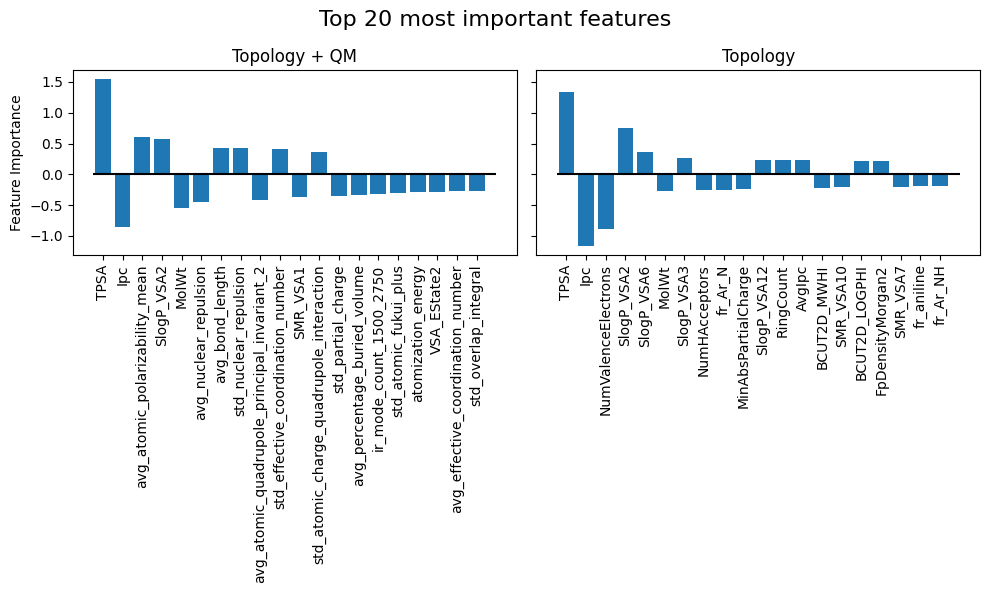

In [134]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

ax1.bar(keys_combo, values_combo)
ax2.bar(keys_topo, values_topo)

ax1.hlines(0, -0.5, 20, "black")
ax2.hlines(0, -0.5, 20, "black")

ax1.tick_params(axis='x', rotation=90)
ax2.tick_params(axis='x', rotation=90)

ax1.set_title("Topology + QM")
ax2.set_title("Topology")

ax1.set_ylabel("Feature Importance")

plt.suptitle("Top 20 most important features", fontsize=16)
plt.tight_layout()
plt.show()